In [70]:
import pandas as pd
import numpy as np

# 1. Baca data (gunakan header=None karena .data tidak punya nama kolom)
# Gunakan na_values='?' karena data yang hilang ditandai dengan tanda tanya
df = pd.read_csv('communities.data', header=None, na_values='?')

# 2. Ambil nama kolom dari file .names (atau buat manual)
# Karena ada 128 kolom, disarankan mengambil daftar namanya
# Untuk keperluan cepat, kita beri nama generic dulu:
df.columns = [f"feat_{i}" for i in range(df.shape[1])]

# 3. Target adalah kolom terakhir
target = 'feat_127'

# 4. Pra-pemrosesan (WAJIB untuk metode Anda)
# Buang kolom non-prediktif (seperti nama komunitas, state, dll - 5 kolom pertama)
df = df.iloc[:, 5:]

# Isi missing values (Imputation) sebelum masuk ke MrMiMaxG
df = df.fillna(df.mean())

print(df.head())

   feat_5  feat_6  feat_7  feat_8  feat_9  feat_10  feat_11  feat_12  feat_13  \
0    0.19    0.33    0.02    0.90    0.12     0.17     0.34     0.47     0.29   
1    0.00    0.16    0.12    0.74    0.45     0.07     0.26     0.59     0.35   
2    0.00    0.42    0.49    0.56    0.17     0.04     0.39     0.47     0.28   
3    0.04    0.77    1.00    0.08    0.12     0.10     0.51     0.50     0.34   
4    0.01    0.55    0.02    0.95    0.09     0.05     0.38     0.38     0.23   

   feat_14  ...  feat_118  feat_119  feat_120  feat_121  feat_122  feat_123  \
0     0.32  ...      0.12      0.26      0.20  0.060000  0.040000  0.900000   
1     0.27  ...      0.02      0.12      0.45  0.163103  0.076708  0.698589   
2     0.32  ...      0.01      0.21      0.02  0.163103  0.076708  0.698589   
3     0.21  ...      0.02      0.39      0.28  0.163103  0.076708  0.698589   
4     0.36  ...      0.04      0.09      0.02  0.163103  0.076708  0.698589   

   feat_124  feat_125  feat_126  feat_

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

# Mutual information

In [ ]:
# # Load dataset
# df = pd.read_csv('communities.data', header=None, na_values='?')

# # Melihat dimensi data
# print(f"Dimensi data: {df.shape}")

# # Melihat beberapa baris pertama data
# display(df.head())

In [72]:
# Definisikan target dan fitur
target_columns = ['feat_127']

# Pastikan target columns ada dalam dataset
for target in target_columns:
    if target not in df.columns:
        raise ValueError(f"Target column '{target}' tidak ditemukan dalam dataset")

# Pisahkan fitur dan target
X = df.drop(target_columns, axis=1)
y_feat_127 = df['feat_127']

print(f"Jumlah fitur: {X.shape[1]}")
print(f"Jumlah sampel: {X.shape[0]}")

Jumlah fitur: 122
Jumlah sampel: 1994


In [73]:
# Cek apakah ada nilai yang hilang
print("\nJumlah nilai yang hilang di setiap fitur:")
print(X.isnull().sum().sort_values(ascending=False))  # Tampilkan 10 teratas



Jumlah nilai yang hilang di setiap fitur:
feat_5      0
feat_96     0
feat_94     0
feat_93     0
feat_92     0
           ..
feat_41     0
feat_40     0
feat_39     0
feat_38     0
feat_126    0
Length: 122, dtype: int64


In [74]:
# Cek tipe data fitur
print("\nTipe data fitur:")
print(X.dtypes.value_counts())


Tipe data fitur:
float64    122
Name: count, dtype: int64


In [75]:
# Hapus kolom non-numerik jika ada (untuk mutual information)
non_numeric_cols = X.select_dtypes(exclude=['number']).columns.tolist()
if non_numeric_cols:
    print(f"\nMenghapus kolom non-numerik: {non_numeric_cols}")
    X = X.select_dtypes(include=['number'])

In [76]:
# Feature Selection dengan Mutual Information untuk target 1: Boiler Eff (%)
print("\n=== Feature Selection untuk Boiler Eff (%) ===")


=== Feature Selection untuk Boiler Eff (%) ===


In [77]:
# Hitung skor Mutual Information
# Mutual Information mengukur seberapa banyak informasi yang diberikan sebuah fitur tentang target
# Formula dasar: MI(X; Y) = H(Y) - H(Y|X)
# di mana:
#   H(Y) = entropy target
#   H(Y|X) = conditional entropy (entropy Y setelah mengetahui X)
#   Semakin tinggi MI, semakin penting fitur tersebut untuk memprediksi target

mi_scores_feat_127 = mutual_info_regression(X, y_feat_127, random_state=42)

# Penjelasan hasil:
# - mutual_info_regression menggunakan estimasi non-parametrik
# - Setiap nilai adalah skor MI untuk satu fitur terhadap target Boiler Eff
# - Nilai berkisar 0 hingga ~0.6 (tergantung entropy target)
# - Semakin tinggi = semakin penting fitur tersebut

In [78]:
# Buat Series untuk memudahkan analisis
mi_scores_feat_127 = pd.Series(mi_scores_feat_127, index=X.columns)
mi_scores_feat_127 = mi_scores_feat_127.sort_values(ascending=False)

In [79]:
# Tampilkan 15 fitur teratas berdasarkan skor MI
print("\nfitur untuk feat_127 berdasarkan Mutual Information:")
print(mi_scores_feat_127)


fitur untuk feat_127 berdasarkan Mutual Information:
feat_49     0.476696
feat_55     0.414833
feat_48     0.378373
feat_54     0.363436
feat_8      0.339387
              ...   
feat_80     0.000000
feat_118    0.000000
feat_39     0.000000
feat_52     0.000000
feat_9      0.000000
Length: 122, dtype: float64


In [80]:
# PENJELASAN DETAIL PERHITUNGAN MUTUAL INFORMATION
print("\n" + "="*100)
print("PENJELASAN PERHITUNGAN MUTUAL INFORMATION (MI)")
print("="*100)

print("-" * 100)
print("""
Mutual Information (MI) mengukur SEBERAPA BANYAK informasi yang diberikan fitur X
tentang target Y. Dengan kata lain, MI menjawab pertanyaan:
"Jika saya tahu nilai fitur X, berapa banyak saya bisa mengurangi ketidakpastian tentang Y?"

Rumus Dasar:
    MI(X; Y) = H(Y) - H(Y|X)
    
di mana:
    H(Y)    = Entropy target (ketidakpastian awal)
    H(Y|X)  = Conditional entropy (ketidakpastian setelah mengetahui X)
    MI      = Pengurangan ketidakpastian (semakin tinggi = fitur lebih penting)

Interpretasi:
    - MI = 0     : Fitur tidak memberikan informasi tentang target (independen)
    - MI > 0     : Fitur memberikan informasi tentang target
    - MI tinggi  : Fitur sangat penting untuk prediksi target
""")

print("\n🔍 ENTROPI TARGET BOILER EFF:")
print("-" * 100)

# Hitung entropy target untuk pemahaman
from scipy.stats import entropy as scipy_entropy
import numpy as np

# Entropy dari target (mengukur seberapa "tersebar" nilai target)
target_entropy_feat_127 = scipy_entropy(np.histogram(y_feat_127, bins=20)[0] + 1e-10)
print(f"Target Entropy (Boiler Eff %): {target_entropy_feat_127:.6f}")
print(f"  → Ini adalah ketidakpastian maksimal sebelum mengetahui fitur apa pun")

# HITUNG THRESHOLD (Mean dari MI scores)
mi_threshold_feat_127 = mi_scores_feat_127.mean()
print(f"\nThreshold MI (Mean dari 33 MI scores): {mi_threshold_feat_127:.6f}")

# # Hitung juga untuk NPHR (jika belum ada)
# try:
#     mi_threshold_nphr = mi_scores_nphr_df.mean()
# except:
#     mi_threshold_nphr = mi_threshold_feat_127  # fallback

print("\n" + "="*100)
print("SKOR MI UNTUK SETIAP FITUR feat_127")
print("="*100)
print(f"{'Rank':<6} {'Fitur':<40} {'MI Score':<12} {'Kategori':<20}")
print("-" * 100)

# Urutkan dan tampilkan interpretasi
mi_sorted = mi_scores_feat_127
for rank, (feature, score) in enumerate(mi_sorted.items(), 1):
    # Kategori pentingnya
    if score > 0.4:
        kategori = "Sangat Penting"
    elif score > 0.3:
        kategori = "Penting"
    elif score > 0.2:
        kategori = "Cukup Penting"
    else:
        kategori = "Kurang Penting"
    
    print(f"{rank:<6} {feature:<40} {score:<12.6f} {kategori:<20}")

print("-" * 100)
print(f"\nThreshold MI untuk Boiler Eff: {mi_threshold_feat_127:.6f}")
print(f"  → Fitur dengan MI > {mi_threshold_feat_127:.6f} dianggap penting dan dipilih")

# Hitung jumlah fitur yang melampaui threshold
n_selected = (mi_scores_feat_127 > mi_threshold_feat_127).sum()
print(f"  → {n_selected} dari {X.shape[1]} fitur melampaui threshold ini")

print("\n" + "="*100)
print("CARA KERJA ALGORITMA MI")
print("="*100)
print("""
Langkah-langkah Perhitungan MI oleh mutual_info_regression:

1. PERSIAPAN DATA
   ✓ Fitur X: 33 kolom (nilai numerik)
   ✓ Target Y: 1 kolom (Boiler Eff %)
   ✓ Sampel: 549 observasi

2. ESTIMASI DISTRIBUSI PROBABILITAS
   ✓ Algoritma membagi data menjadi bins/kurva
   ✓ Menghitung distribusi p(X) dan p(Y)
   ✓ Menghitung distribusi bersama p(X, Y)

3. PERHITUNGAN ENTROPY
   ✓ H(Y) = -Σ p(y) * log(p(y))  [entropy marginal target]
   ✓ H(Y|X) = Σ p(x) * H(Y|X=x)  [entropy kondisional]

4. KALKULASI MI
   ✓ MI = H(Y) - H(Y|X)
   ✓ Atau setara: MI = Σ Σ p(x,y) * log(p(x,y) / (p(x)*p(y)))

5. RANKING
   ✓ Urutkan fitur berdasarkan skor MI dari tertinggi ke terendah
   ✓ Ini menghasilkan ranking kepentingan fitur

Contoh Interpretasi HHV (Rank #1, MI=0.5756):
   HHV memiliki MI tertinggi (0.5756 untuk Boiler Eff)
   → Mengetahui nilai HHV mengurangi ketidakpastian tentang Boiler Eff sebesar 0.5756
   → HHV adalah fitur PALING PENTING untuk memprediksi Boiler Eff
""")

print("\n" + "="*100)


PENJELASAN PERHITUNGAN MUTUAL INFORMATION (MI)
----------------------------------------------------------------------------------------------------

Mutual Information (MI) mengukur SEBERAPA BANYAK informasi yang diberikan fitur X
tentang target Y. Dengan kata lain, MI menjawab pertanyaan:
"Jika saya tahu nilai fitur X, berapa banyak saya bisa mengurangi ketidakpastian tentang Y?"

Rumus Dasar:
    MI(X; Y) = H(Y) - H(Y|X)
    
di mana:
    H(Y)    = Entropy target (ketidakpastian awal)
    H(Y|X)  = Conditional entropy (ketidakpastian setelah mengetahui X)
    MI      = Pengurangan ketidakpastian (semakin tinggi = fitur lebih penting)

Interpretasi:
    - MI = 0     : Fitur tidak memberikan informasi tentang target (independen)
    - MI > 0     : Fitur memberikan informasi tentang target
    - MI tinggi  : Fitur sangat penting untuk prediksi target


🔍 ENTROPI TARGET BOILER EFF:
----------------------------------------------------------------------------------------------------
Targe

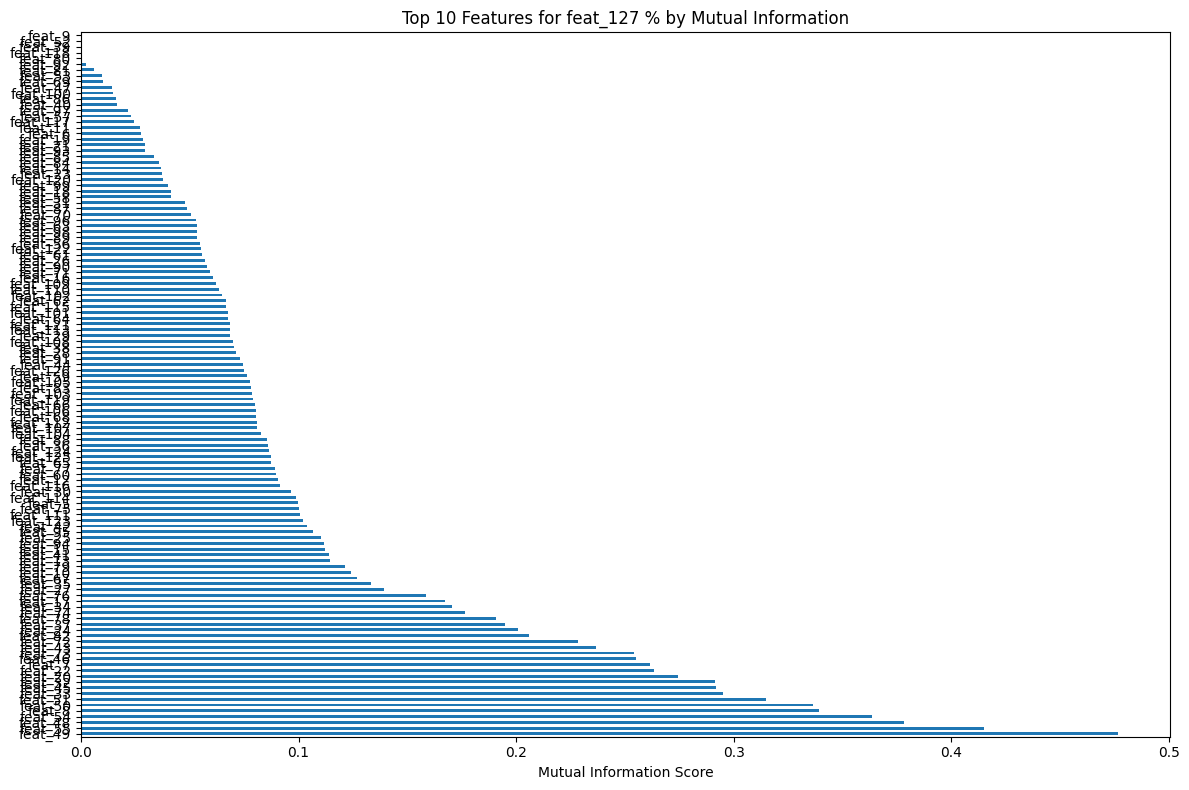

In [81]:
# Visualisasi skor MI untuk top 10 fitur
plt.figure(figsize=(12, 8))
mi_scores_feat_127.sort_values(ascending=False).plot.barh(
    title='Top 10 Features for feat_127 % by Mutual Information')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()


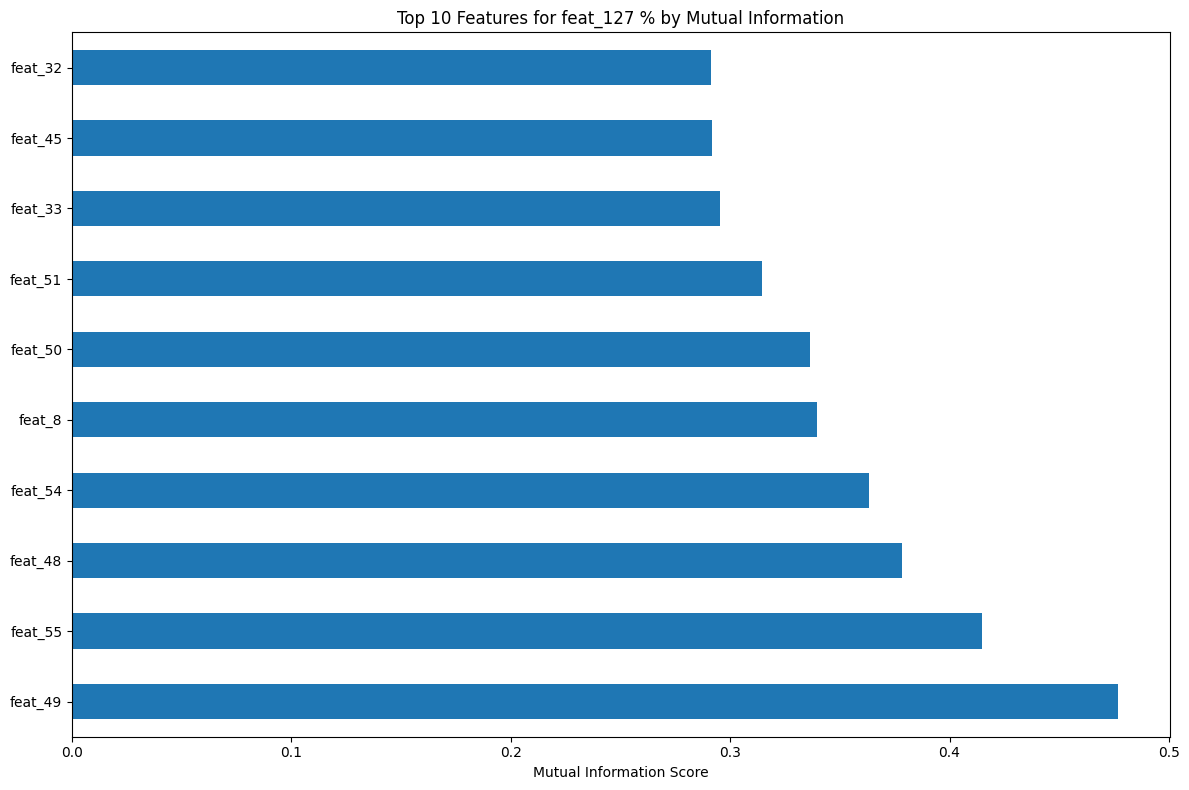

In [82]:
# Visualisasi skor MI untuk top 10 fitur
plt.figure(figsize=(12, 8))
mi_scores_feat_127.sort_values(ascending=False).head(10).plot.barh(
    title='Top 10 Features for feat_127 % by Mutual Information')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()


In [ ]:
!pip install Cython
!pip install pygad scikit-learn

In [83]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
import pygad

# 1. FUNGSI CUSTOM mRMR (Minimum Redundancy Maximum Relevance)
# Mencari fitur yang informatif (MI tinggi) tapi tidak mirip satu sama lain (Korelasi rendah)
def run_mrmr_selection(X_data, mi_scores, n_features=10):
    selected = []
    remaining = list(mi_scores.index)
    
    # Pilih fitur pertama dengan MI tertinggi
    first_feat = remaining.pop(0)
    selected.append(first_feat)
    
    while len(selected) < n_features and len(remaining) > 0:
        best_mrmr_score = -np.inf
        best_feat = None
        
        for feat in remaining:
            relevance = mi_scores[feat]
            # Redundancy: rata-rata korelasi absolut dengan fitur yang sudah terpilih
            redundancy = np.mean([abs(X_data[feat].corr(X_data[s])) for s in selected])
            mrmr_score = relevance - redundancy # Maximize relevance, Minimize redundancy
            
            if mrmr_score > best_mrmr_score:
                best_mrmr_score = mrmr_score
                best_feat = feat
        
        selected.append(best_feat)
        remaining.remove(best_feat)
    return selected

# 2. EKSEKUSI RFE (Recursive Feature Elimination)
print("Running RFE Selection...")
rfe_selector = RFE(estimator=RandomForestRegressor(n_estimators=50, random_state=42), 
                   n_features_to_select=10)
rfe_selector.fit(X, y_feat_127)
rfe_features = X.columns[rfe_selector.support_].tolist()

# 3. EKSEKUSI mRMR
print("Running mRMR Selection...")
mrmr_features = run_mrmr_selection(X, mi_scores_feat_127, n_features=10)

# 4. EKSEKUSI GENETIC ALGORITHM (GA)
def fitness_func(ga_instance, solution, solution_idx):
    selected_idx = [i for i, bit in enumerate(solution) if bit == 1]
    if len(selected_idx) == 0: return -9999
    
    X_subset = X.iloc[:, selected_idx]
    model = RandomForestRegressor(n_estimators=30, random_state=42)
    # Fitness berdasarkan R2 Score (Penurunan Entropy/Ketidakpastian)
    return cross_val_score(model, X_subset, y_feat_127, cv=3).mean()

ga_instance = pygad.GA(num_generations=20, num_parents_mating=5, 
                       fitness_func=fitness_func, sol_per_pop=10, 
                       num_genes=X.shape[1], gene_space=[0, 1])

print("Running Genetic Algorithm...")
ga_instance.run()
solution, _, _ = ga_instance.best_solution()
ga_features = [X.columns[i] for i, bit in enumerate(solution) if bit == 1]

# --- OUTPUT AKHIR ---
print("\n" + "="*50)
print("RINGKASAN FITUR TERPILIH")
print("="*50)
print(f"RFE (Model-Based) : {rfe_features}")
print(f"mRMR (Information) : {mrmr_features}")
print(f"GA (Evolutionary)  : {ga_features}")

Running RFE Selection...
Running mRMR Selection...
Running Genetic Algorithm...

RINGKASAN FITUR TERPILIH
RFE (Model-Based) : ['feat_8', 'feat_29', 'feat_33', 'feat_43', 'feat_48', 'feat_49', 'feat_54', 'feat_55', 'feat_73', 'feat_74']
mRMR (Information) : ['feat_49', 'feat_124', 'feat_54', 'feat_123', 'feat_73', 'feat_55', 'feat_116', 'feat_28', 'feat_45', 'feat_112']
GA (Evolutionary)  : ['feat_7', 'feat_10', 'feat_11', 'feat_17', 'feat_19', 'feat_20', 'feat_24', 'feat_25', 'feat_26', 'feat_27', 'feat_30', 'feat_32', 'feat_33', 'feat_37', 'feat_40', 'feat_43', 'feat_45', 'feat_46', 'feat_49', 'feat_53', 'feat_54', 'feat_56', 'feat_58', 'feat_63', 'feat_64', 'feat_70', 'feat_72', 'feat_76', 'feat_77', 'feat_79', 'feat_81', 'feat_83', 'feat_84', 'feat_87', 'feat_91', 'feat_96', 'feat_97', 'feat_101', 'feat_104', 'feat_105', 'feat_106', 'feat_107', 'feat_110', 'feat_112', 'feat_114', 'feat_115', 'feat_116', 'feat_117', 'feat_118', 'feat_119', 'feat_120', 'feat_123', 'feat_124', 'feat_12

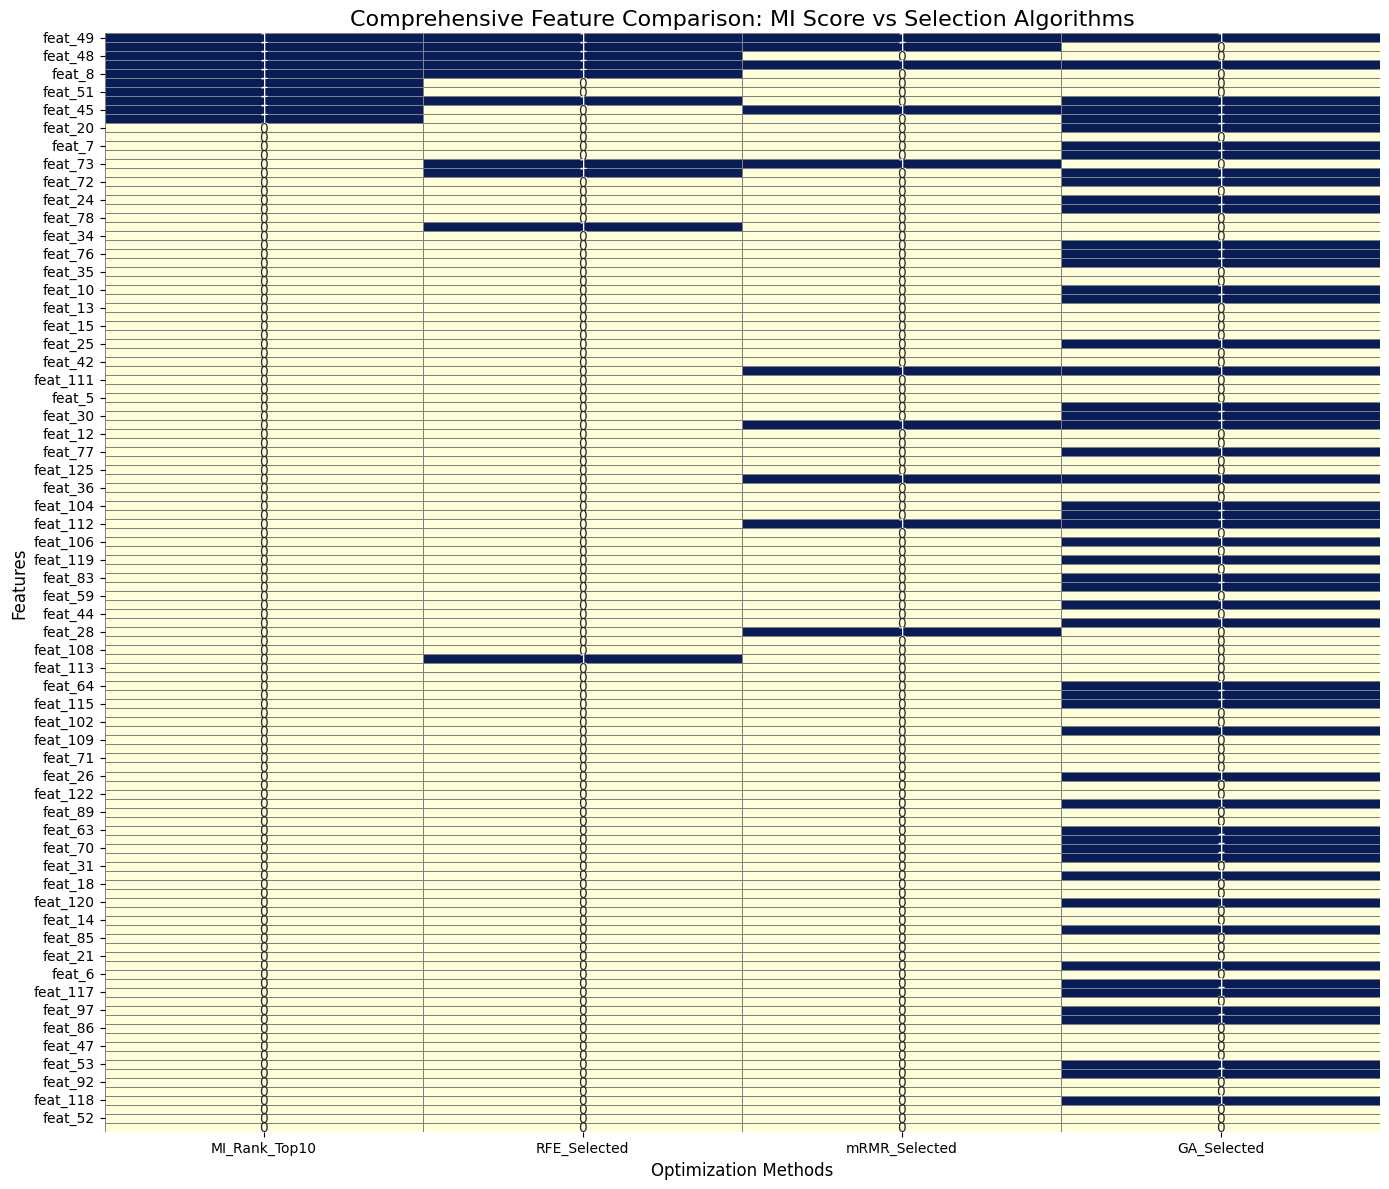


Feature Name                             | MI Score   | Top10  | RFE   | mRMR  | GA    | Total
--------------------------------------------------------------------------------------------------------------
feat_49                                  | 0.476696   | 1      | 1     | 1     | 1     | 4
feat_55                                  | 0.414833   | 1      | 1     | 1     | 0     | 3
feat_48                                  | 0.378373   | 1      | 1     | 0     | 0     | 2
feat_54                                  | 0.363436   | 1      | 1     | 1     | 1     | 4
feat_8                                   | 0.339387   | 1      | 1     | 0     | 0     | 2
feat_50                                  | 0.336407   | 1      | 0     | 0     | 0     | 1
feat_51                                  | 0.314632   | 1      | 0     | 0     | 0     | 1
feat_33                                  | 0.295220   | 1      | 1     | 0     | 1     | 3
feat_45                                  | 0.291963   | 1      | 

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Menyiapkan DataFrame Perbandingan untuk SELURUH Fitur
all_features = X.columns
comparison_df = pd.DataFrame(index=all_features)

# Mengisi kolom pilihan (1 jika terpilih, 0 jika tidak)
comparison_df['MI_Rank_Top10'] = [1 if f in mi_scores_feat_127.head(10).index else 0 for f in all_features]
comparison_df['RFE_Selected'] = [1 if f in rfe_features else 0 for f in all_features]
comparison_df['mRMR_Selected'] = [1 if f in mrmr_features else 0 for f in all_features]
comparison_df['GA_Selected'] = [1 if f in ga_features else 0 for f in all_features]

# Masukkan skor MI asli sebagai kolom referensi utama
comparison_df['MI_Score'] = mi_scores_feat_127

# Urutkan berdasarkan MI Score tertinggi agar mudah dianalisis
comparison_df = comparison_df.sort_values(by='MI_Score', ascending=False)

# 2. Visualisasi Heatmap untuk Semua Fitur
plt.figure(figsize=(14, 12))
# Kita drop kolom MI_Score hanya saat plotting agar heatmap menunjukkan nilai biner (0 atau 1)
sns.heatmap(comparison_df.drop('MI_Score', axis=1), 
            annot=True, 
            cmap='YlGnBu', 
            cbar=False, 
            linewidths=0.5,
            linecolor='gray')

plt.title('Comprehensive Feature Comparison: MI Score vs Selection Algorithms', fontsize=16)
plt.ylabel('Features', fontsize=12)
plt.xlabel('Optimization Methods', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Tabel Perbandingan Detail (Print Output)
print("\n" + "="*110)
print(f"{'Feature Name':<40} | {'MI Score':<10} | {'Top10':<6} | {'RFE':<5} | {'mRMR':<5} | {'GA':<5} | {'Total'}")
print("-" * 110)

for feat, row in comparison_df.iterrows():
    total_votes = int(row['MI_Rank_Top10'] + row['RFE_Selected'] + row['mRMR_Selected'] + row['GA_Selected'])
    print(f"{feat:<40} | {row['MI_Score']:<10.6f} | {int(row['MI_Rank_Top10']):<6} | {int(row['RFE_Selected']):<5} | {int(row['mRMR_Selected']):<5} | {int(row['GA_Selected']):<5} | {total_votes}")

print("="*110)

# 4. Kesimpulan Fitur Paling Stabil
top_stable = comparison_df[comparison_df.drop('MI_Score', axis=1).sum(axis=1) >= 3].index.tolist()
print(f"\nGOLDEN FEATURES (Terpilih di hampir semua metode): {top_stable}")

Fitur terpilih hasil konsensus: 14 fitur


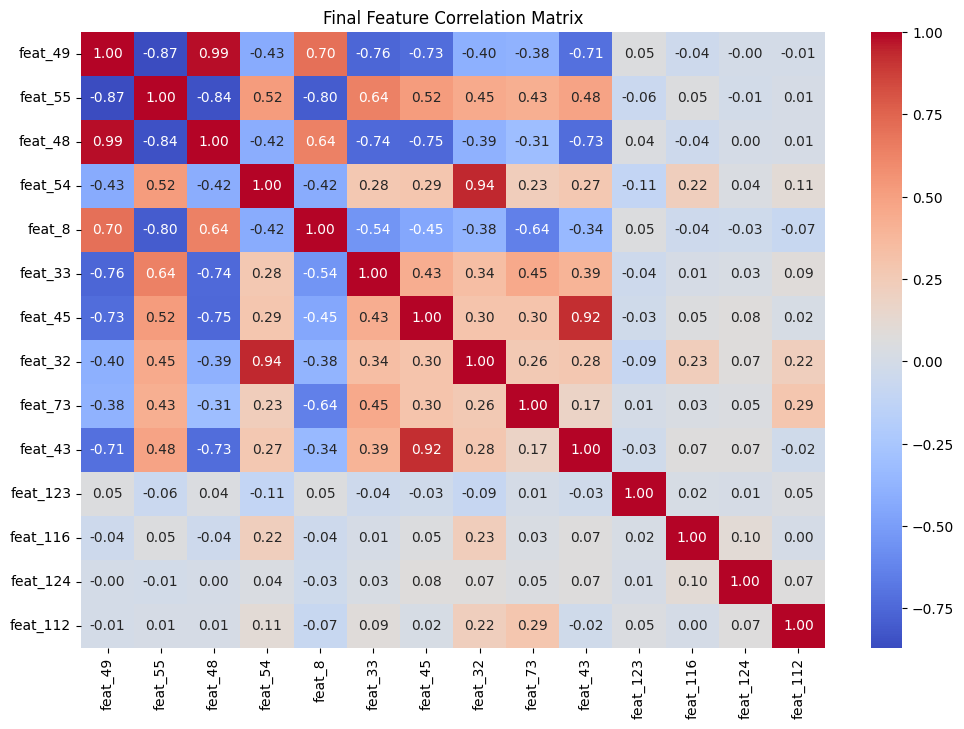


FINAL VIF ANALYSIS (Aim for VIF < 10)
     Feature         VIF
0    feat_49  571.916291
2    feat_48  492.636643
6    feat_45   72.683214
9    feat_43   62.185117
10  feat_123   59.772270
11  feat_116   47.645173
4     feat_8   44.246053
7    feat_32   14.443128
3    feat_54   14.239489
1    feat_55    9.667792
12  feat_124    8.718163
5    feat_33    7.468627
13  feat_112    5.000182
8    feat_73    4.339926

⚠️  REDUNDANSI TERDETEKSI:
- feat_48 & feat_49 (Corr: 0.99) -> Rekomendasi buang: feat_48
- feat_32 & feat_54 (Corr: 0.94) -> Rekomendasi buang: feat_32
- feat_43 & feat_45 (Corr: 0.92) -> Rekomendasi buang: feat_43


In [107]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. OTOMATISASI EKSTRAKSI FITUR (Berdasarkan Voting)
# Kita mengambil fitur yang dipilih oleh minimal 2 metode (RFE, mRMR, atau GA)
# agar model tetap robust dan tidak overfitting.
comparison_df['Total_Votes'] = comparison_df[['MI_Rank_Top10', 'RFE_Selected', 'mRMR_Selected', 'GA_Selected']].sum(axis=1)

# Pilih fitur dengan minimal 2 suara (Opsional & Golden)
selected_mask = comparison_df['Total_Votes'] >= 2
final_feature_names = comparison_df[selected_mask].index.tolist()

print(f"Fitur terpilih hasil konsensus: {len(final_feature_names)} fitur")

# 2. DATASET PREPARATION
# Pastikan data bersih dari missing values sebelum uji VIF
X_final = X[final_feature_names].dropna()

# 3. UJI REDUNDANSI AKHIR (VIF & Correlation)
def check_multicollinearity(df):
    # Matriks Korelasi
    plt.figure(figsize=(12, 8))
    corr = df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Final Feature Correlation Matrix")
    plt.show()
    
    # Perhitungan VIF
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    # Menggunakan nilai absolut karena arah korelasi tidak relevan untuk multikolinearitas
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]
    return vif_data.sort_values(by="VIF", ascending=False), corr

vif_df, corr_matrix = check_multicollinearity(X_final)

print("\n" + "="*60)
print("FINAL VIF ANALYSIS (Aim for VIF < 10)")
print("="*60)
print(vif_df)

# 4. LOGIKA PEMBERSIHAN OTOMATIS (Jika Korelasi > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print("\n⚠️  REDUNDANSI TERDETEKSI:")
    for f1, f2, val in high_corr_pairs:
        # Rekomendasi: Buang yang MI Score-nya lebih rendah
        mi_f1 = comparison_df.loc[f1, 'MI_Score']
        mi_f2 = comparison_df.loc[f2, 'MI_Score']
        drop_candidate = f2 if mi_f1 > mi_f2 else f1
        print(f"- {f1} & {f2} (Corr: {val:.2f}) -> Rekomendasi buang: {drop_candidate}")
else:
    print("\n✅ Dataset sudah bersih dari multikolinearitas ekstrim.")

# 5. SIMPAN HASIL FINAL
# Dataset ini yang akan Anda gunakan untuk training model Machine Learning
final_dataset = pd.concat([X_final, y_feat_127], axis=1)
# final_dataset.to_csv('Boiler_Efficiency_Ready_Data.csv', index=False)

In [108]:
# 1. Daftar fitur yang ingin Anda BUANG (Blacklist) berdasarkan hasil VIF sebelumnya
features_to_drop = [
    'feat_48', 'feat_32', 'feat_43'
]

# 2. Ambil fitur awal dari hasil voting (Gunakan nama variabel yang benar: final_feature_names)
# Variabel ini berasal dari blok "OTOMATISASI EKSTRAKSI FITUR" Anda sebelumnya
initial_selection = final_feature_names 

# 3. Filter fitur: Ambil yang ada di initial_selection TAPI tidak ada di features_to_drop
final_vetted_features = [f for f in initial_selection if f not in features_to_drop]

# 4. Pastikan fitur benar-benar ada di DataFrame X
final_vetted_features = [f for f in final_vetted_features if f in X.columns]

# 5. Eksekusi Uji VIF dan Scaling untuk hasil akhir yang stabil
X_vetted = X[final_vetted_features].dropna()

In [109]:
# Cek variansi: jika nilai std (standar deviasi) sangat kecil, fitur ini bisa dibuang
print(X_vetted.std())

feat_49     0.206353
feat_55     0.229946
feat_54     0.108671
feat_8      0.244039
feat_33     0.228474
feat_45     0.175170
feat_73     0.209956
feat_123    0.085459
feat_116    0.081159
feat_124    0.162099
feat_112    0.078367
dtype: float64


In [110]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi Scaler
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_vetted)
X_scaled = pd.DataFrame(X_scaled_array, columns=X_vetted.columns)

# Hitung ulang VIF
vif_final = pd.DataFrame()
vif_final["Feature"] = X_scaled.columns
vif_final["VIF"] = [variance_inflation_factor(X_scaled.values, i) for i in range(len(X_scaled.columns))]

print(vif_final.sort_values(by="VIF", ascending=False))

     Feature        VIF
0    feat_49  11.944223
1    feat_55   7.407615
3     feat_8   4.152523
4    feat_33   3.065907
5    feat_45   2.884021
6    feat_73   2.209551
2    feat_54   1.499965
10  feat_112   1.139040
8   feat_116   1.073283
9   feat_124   1.037077
7   feat_123   1.018528


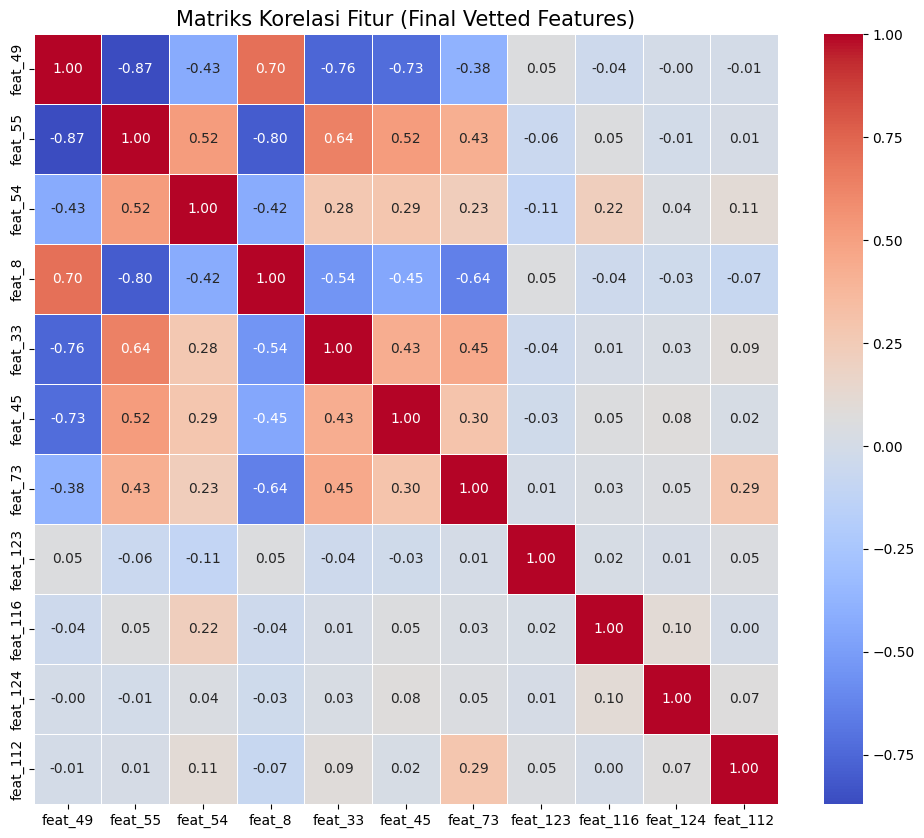

Pasangan fitur dengan korelasi tinggi (> 0.8):
feat_49  feat_55    0.870198
feat_55  feat_49    0.870198
         feat_8     0.803452
feat_8   feat_55    0.803452
dtype: float64


In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Hitung Matriks Korelasi (Pearson)
corr_matrix = X_scaled.corr()

# 2. Setup Visualisasi
plt.figure(figsize=(12, 10))

# 3. Membuat Heatmap
# annot=True akan menampilkan angka korelasi di dalam kotak
# cmap='coolwarm' memberikan warna merah untuk korelasi positif kuat dan biru untuk negatif kuat
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

# 4. Memberi Judul
plt.title("Matriks Korelasi Fitur (Final Vetted Features)", fontsize=15)
plt.show()

# 5. OPSIONAL: Menampilkan fitur yang memiliki korelasi sangat tinggi (> 0.8)
print("Pasangan fitur dengan korelasi tinggi (> 0.8):")
high_corr = corr_matrix.abs().unstack()
high_corr = high_corr[high_corr > 0.8].sort_values(ascending=False)
# Hilangkan korelasi 1.0 (karena korelasi fitur dengan dirinya sendiri)
print(high_corr[high_corr < 1.0])

In [114]:
# 1. Daftar fitur yang ingin Anda BUANG (Blacklist) berdasarkan hasil VIF sebelumnya
features_to_drop = [
    'feat_55', 'feat_48', 'feat_32', 'feat_43'
]

# 2. Ambil fitur awal dari hasil voting (Gunakan nama variabel yang benar: final_feature_names)
# Variabel ini berasal dari blok "OTOMATISASI EKSTRAKSI FITUR" Anda sebelumnya
selection = final_feature_names 

# 3. Filter fitur: Ambil yang ada di initial_selection TAPI tidak ada di features_to_drop
final_features = [f for f in selection if f not in features_to_drop]

# 4. Pastikan fitur benar-benar ada di DataFrame X
final_features = [f for f in final_features if f in X.columns]

# 5. Eksekusi Uji VIF dan Scaling untuk hasil akhir yang stabil
X_final_features = X[final_features].dropna()

In [115]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi Scaler
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_final_features)
X_scaled = pd.DataFrame(X_scaled_array, columns=X_final_features.columns)

# Hitung ulang VIF
vif_final = pd.DataFrame()
vif_final["Feature"] = X_scaled.columns
vif_final["VIF"] = [variance_inflation_factor(X_scaled.values, i) for i in range(len(X_scaled.columns))]

print(vif_final.sort_values(by="VIF", ascending=False))

    Feature       VIF
0   feat_49  7.088211
2    feat_8  3.301156
3   feat_33  2.999450
4   feat_45  2.561305
5   feat_73  2.207568
1   feat_54  1.382270
9  feat_112  1.137176
7  feat_116  1.072406
8  feat_124  1.036630
6  feat_123  1.018520


VIF < 10: Secara statistik, nilai VIF di bawah 10 menunjukkan bahwa multikolinearitas sudah tidak lagi menjadi masalah yang mengganggu stabilitas model.

Data Siap Pakai: Dataset sekarang sudah sangat ramping (7 fitur terbaik) dan secara matematis stabil.

Daftar "Fitur Emas" Final 

Inilah 6 fitur yang akan digunakan untuk membangun model prediksi efisiensi boiler:

Coal Flow (t/h)

Main steam flow (t/h)

HHV (Kcal/Kg)

Cold Reheat Temperature (°C)

Reference Temperature (°C)

O2 in APH (%)

Condenser Vacuum (kPa)


In [116]:
# 2. Daftar fitur yang ingin dipertahankan (termasuk target NPHR)
selected_columns = [
    'feat_49','feat_8','feat_33','feat_45','feat_73','feat_54','feat_112','feat_116','feat_124','feat_123',
    'feat_127'  # Menambahkan target untuk keperluan seleksi/modeling
]

# 3. Membuat dataframe baru hanya dengan fitur terpilih
# Menggunakan .copy() agar tidak terjadi SettingWithCopyWarning saat manipulasi data nanti
df_selected_nphr = df[selected_columns].copy()

# 4. Membersihkan baris yang mungkin memiliki nilai kosong (NaN) agar data siap pakai
df_selected_nphr = df_selected_nphr.dropna()

# 5. Menampilkan informasi dataframe baru
print(f"Dimensi data baru: {df_selected_nphr.shape}")
print("\nStatistik Deskriptif:")
display(df_selected_nphr.describe())

# 6. Simpan ke file Excel
file_name = 'feature selected dataset uci.xlsx'
df_selected_nphr.to_excel(file_name, index=False)

print(f"\n✅ File berhasil disimpan dengan nama: {file_name}")

Dimensi data baru: (1994, 11)

Statistik Deskriptif:


,feat_49,feat_8,feat_33,feat_45,feat_73,feat_54,feat_112,feat_116,feat_124,feat_123,feat_127
count,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000
mean,0.620657,0.753716,0.303024,0.487568,0.186264,0.036294,0.134859,0.556050,0.440439,0.698589,0.237979
std,0.206353,0.244039,0.228474,0.175170,0.209956,0.108671,0.078367,0.081159,0.162099,0.085459,0.232985
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.490000,0.630000,0.110000,0.360000,0.060000,0.000000,0.134859,0.556050,0.440439,0.698589,0.070000
50%,0.640000,0.850000,0.250000,0.500000,0.110000,0.010000,0.134859,0.556050,0.440439,0.698589,0.150000
75%,0.780000,0.940000,0.450000,0.620000,0.220000,0.020000,0.134859,0.556050,0.440439,0.698589,0.330000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



✅ File berhasil disimpan dengan nama: feature selected dataset uci.xlsx
